# Assignemt 01 - Sentiment Analysis

<details>
  <summary><span style="font-size:1.5em; font-weight:bold; color:#1f77b4;">Problem Statement</span></summary>

  <p>

### Sentiment Analysis Using TF-IDF Vectors

**Objective:**  
Design and implement a machine learning model to perform sentiment analysis on a given dataset containing textual data and corresponding sentiment labels. The analysis should use **TF-IDF (Term Frequency-Inverse Document Frequency)** vectors to transform the text into numerical features and classify the sentiments effectively.

### Dataset Description for Sentiment Analysis Project

**Content:**  
The dataset is stored in a **CSV file** and includes six fields:

1. **Polarity (Column 0):**  
   - Sentiment label for the tweet:  
     - `0`: Negative sentiment  
     - `2`: Neutral sentiment  
     - `4`: Positive sentiment

2. **Tweet ID (Column 1):**  
   - A unique identifier for each tweet.

3. **Date (Column 2):**  
   - The timestamp of when the tweet was posted, in the format:  
     `Day Month Date HH:MM:SS UTC Year`  
     *(e.g., Sat May 16 23:58:44 UTC 2009)*

4. **Query (Column 3):**  
   - The search query used to retrieve the tweet.  
     If no query was used, the value is `NO_QUERY`.

5. **User (Column 4):**  
   - The username of the account that posted the tweet  
     *(e.g., robotickilldozr)*

6. **Text (Column 5):**  
   - The content of the tweet, consisting of raw text after emoticons have been removed  
     *(e.g., Lyx is cool)*

[Dataset Source on Kaggle](https://www.kaggle.com/datasets/abhi8923shriv/sentiment-analysis-dataset/data)
  </p>
</details>

## Imports

In [49]:
# import kagglehub
import html
import re
import string 

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import emoji
import contractions

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, balanced_accuracy_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [6]:
# Download NLTK resources if needed
try:
    nltk.data.find('tokenizers/punkt')
    nltk.data.find('tokenizers/punkt_tab')
    nltk.data.find('corpora/stopwords')
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('punkt')
    nltk.download('punkt_tab')
    nltk.download('stopwords')
    nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\raad\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\raad\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\raad\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\raad\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## 📊 EDA

In this study, we focus exclusively on the `training.1600000.processed.noemoticon.csv` dataset, deliberately excluding the `train.csv` and `test.csv` files from our analysis. This choice is motivated by the richness and scale of the selected dataset, which contains ~1 million tweets and offers a more comprehensive foundation for sentiment analysis.

To begin, we load the dataset and perform initial preprocessing steps. Specifically, we rename the columns `polarity of tweet\xa0` and `text of the tweet\xa0` to `polarity` and `text`, respectively, to simplify references and improve code readability throughout the notebook.

In [7]:
train_df = pd.read_csv("../Data/train_data.csv", encoding="Windows-1252")
train_df.rename(
    columns={
        'polarity of tweet\xa0' : 'polarity',
        'text of the tweet\xa0' : 'text'
    },
    inplace = True
)

train_df.head()

,polarity,id of the tweet,date of the tweet,query,user,text
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew


The dataset also includes additional fields such as `id of the tweet`, `date of the tweet`, `query`, and `user`. However, these fields are not relevant for our sentiment analysis task and will be discarded. We retain only the `polarity` and `text` columns, which contain the sentiment label and the tweet content—our primary variables of interest.

In [8]:
train_df = train_df[["text", "polarity"]]

print(f"train has {len(train_df)} rows")

train has 1048572 rows


Before proceeding with further analysis, we perform a preliminary check for missing values in the dataset. This step ensures data integrity and helps avoid unexpected issues during preprocessing or modeling.

In [9]:
print("train Nans")
print(train_df.isnull().sum())

train Nans
text        0
polarity    0
dtype: int64


Upon inspection, we confirm that there are no missing values in the dataset. This allows us to move forward confidently with the sentiment analysis pipeline without the need for imputation or data cleaning related to null entries.

To prepare the tweet content for analysis, we apply a basic text cleaning function. This step helps standardize the input and remove superficial variations that do not affect sentiment.
Specifically, we:

- Decode any HTML entities,
- Normalize whitespace,
- Convert all text to lowercase,
- Strip leading and trailing spaces.

These transformations ensure consistency across the dataset, as variations in capitalization or spacing do not carry meaningful sentiment information. The cleaning function used is as follows:

In [10]:
def basic_text_clean(text):
    text = html.unescape(text)
    text = re.sub(r'\s+', ' ', text)
    text = text.lower()
    text = text.strip()
    return text

In [11]:
train_df["text"] = train_df["text"].apply(basic_text_clean)

With the text now standardized, we proceed to check for duplicate entries in the dataset. Duplicate tweets can introduce bias and inflate the influence of repeated content, which may distort the sentiment distribution and model performance.

In [12]:
has_duplicates = train_df.duplicated().any()

print("train_df has duplicates:", has_duplicates)

train_df has duplicates: True


Upon inspection, we find that the dataset does contain duplicate entries. To ensure the integrity and diversity of the data, we remove all duplicates based on the text column. This step helps reduce redundancy and ensures that each tweet contributes uniquely to the sentiment analysis process.

In [13]:
before = len(train_df)

train_df.drop_duplicates(inplace=True)

print(f"{before - len(train_df)} rows are dropped")

print(f"dataset has {len(train_df)} rows")

15020 rows are dropped
dataset has 1033552 rows


Some text showed some garbled text, such as `ñ†ñ–ðºð°ð²ð¾ ñ‰ð¾ ð¿ñ€ð°ð²ð¾ð¾ñ…ð¾ñ€ð¾ð½ð½ñ– ð...`

In [14]:
def is_garbled(text, threshold=0.5):
    non_alpha_ratio = len(re.findall(r'[^a-zA-Z\s]', text)) / max(len(text), 1)
    return non_alpha_ratio > threshold

In [15]:
before = len(train_df)

train_df = train_df[~train_df["text"].apply(is_garbled)]

print(f"{before - len(train_df)} rows are dropped")

print(f"dataset has {len(train_df)} rows")

667 rows are dropped
dataset has 1032885 rows


Next, we examine the distribution of the target variable, `polarity`, which indicates the sentiment of each tweet. The dataset uses two labels:  
- `0` for **negative** sentiment  
- `4` for **positive** sentiment

A quick visualization reveals a **highly imbalanced** distribution. The number of negative tweets (polarity `0`) is significantly greater than the number of positive tweets (polarity `4`). Specifically, there are close to **800,000 negative samples** compared to just under **300,000 positive samples**.

This imbalance is an important consideration for model training, as it may lead to biased predictions favoring the majority class. We will address this issue in later stages of the pipeline.

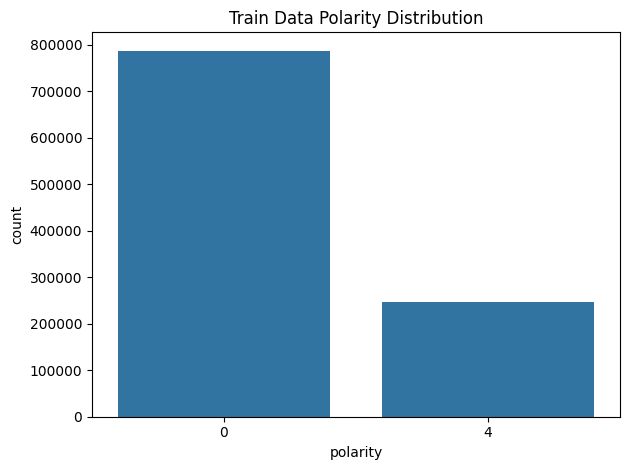

In [16]:
# Train data polarity distribution
sns.countplot(data=train_df, x="polarity")
plt.title("Train Data Polarity Distribution")

plt.tight_layout()

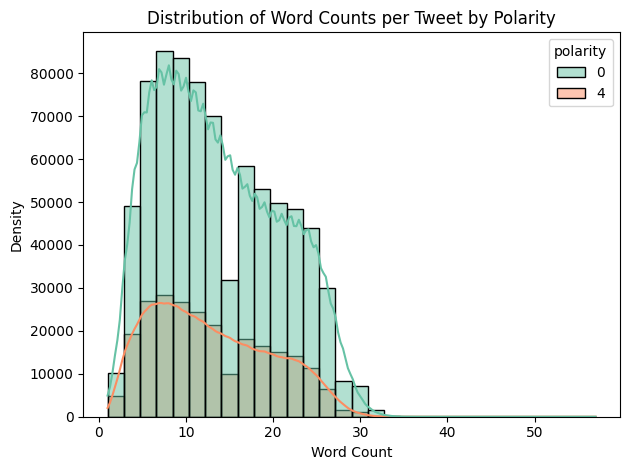

In [17]:
# Calculate word counts
train_df['word_count'] = train_df['text'].astype(str).apply(lambda x: len(x.split()))

# Plot KDE with hue based on polarity

sns.histplot(data=train_df, x='word_count', hue='polarity', kde=True, common_norm=False, palette='Set2', bins=30)
plt.title('Distribution of Word Counts per Tweet by Polarity')
plt.xlabel('Word Count')
plt.ylabel('Density')
plt.tight_layout()

The plot above illustrates the distribution of word counts per tweet, differentiated by sentiment polarity. It combines a histogram with KDE (Kernel Density Estimation) overlays to provide both frequency and smooth density estimates.

- **Polarity 0 (Negative)** tweets are shown in green.
- **Polarity 4 (Positive)** tweets are shown in orange.

Both distributions peak around **10 words**, indicating that most tweets—regardless of sentiment—are relatively short. However, tweets with negative sentiment (polarity 0) are more frequent across all word count ranges, reflecting the earlier observation of class imbalance.

This visualization helps us understand the typical length of tweets and confirms that tweet length does not vary significantly between sentiment classes, though the volume of negative tweets is consistently higher.

## 📝 Text Preprocessing

To enhance the quality of the textual data for sentiment analysis, we apply a more comprehensive preprocessing pipeline. This includes removing URLs, HTML tags, and hashtags (while retaining the associated text), followed by tokenization. We then eliminate stopwords to reduce noise and apply lemmatization to normalize word forms. Additional cleaning steps include removing numerical characters and punctuation. These transformations help reduce variability in the data and ensure that the model focuses on semantically meaningful content, ultimately improving the robustness of downstream analysis and classification.

During preprocessing, we observed that many tweets contain informal contractions such as *"gonna"*, *"I'm"*, or *"don't"*, which can negatively affect tokenization and downstream analysis. To address this, we use `contractions.fix()` to expand these expressions into their full forms (e.g., `"I'm gonna do it 😁"` becomes `"I am going to do it 😁"`), improving clarity and consistency.

Additionally, tweets often include emojis, which can carry strong sentiment signals. Instead of removing them, we apply `emoji.demojize()` to convert emojis into descriptive text (e.g., `😁` becomes `:beaming_face_with_smiling_eyes:`), allowing us to retain their emotional context for sentiment classification.

In [18]:
emoji.demojize("😁")

':beaming_face_with_smiling_eyes:'

In [19]:
texts = [
    "I'm gonna do it 😁",
    "I dunno",
    "I don't know",
]

for text in texts:
    print(f"Original: {text}")
    print(f"Fixed   : {contractions.fix(text)}")

Original: I'm gonna do it 😁
Fixed   : I am going to do it 😁
Original: I dunno
Fixed   : I do not know
Original: I don't know
Fixed   : I do not know


In [20]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english')) - {"no", "nor", "not"} # We keep negations

def text_preprocess(text):
    # Remove urls
    text = re.sub(r'(https?://\S+|www\.\S+|\b\w+\.(com|org|net|edu|gov|info|io|co|me|ai)\b\S*)', '', text)
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Remove user mentions
    text = re.sub(r'@\w+', '', text)
    # Fix contractions
    text = contractions.fix(text)
    if not isinstance(text, str):
        raise ValueError("text should be a string")
    # De-emojize
    text = emoji.demojize(text)
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove punctuation
    text = re.sub(r'[{}]'.format(re.escape(string.punctuation)), ' ', text).strip()
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords
    tokens = [token for token in tokens if token not in stop_words]
    # Lemmatize
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    # Join tokens back into text
    text = ' '.join(tokens)
    return text

In [21]:
text_preprocess("http://www.google.com is not #awesome! 😔")

'not awesome pensive face'

The advanced preprocessing function is computationally intensive and takes approximately 5 to 6 minutes to process the entire dataset. 

In [22]:
train_df["preprocessed_text"] = train_df["text"].apply(text_preprocess)

Checking the top 20 texts

In [23]:
train_df[["text", "preprocessed_text"]].head(10)

,text,preprocessed_text
0,is upset that he can't update his facebook by ...,upset not update facebook texting might cry re...
1,@kenichan i dived many times for the ball. man...,dived many time ball managed save rest go bound
2,my whole body feels itchy and like its on fire,whole body feel itchy like fire
3,"@nationwideclass no, it's not behaving at all....",no not behaving mad not see
4,@kwesidei not the whole crew,not whole crew
5,need a hug,need hug
6,@loltrish hey long time no see! yes.. rains a ...,hey long time no see yes rain bit bit lol fine...
7,i just re-pierced my ears,pierced ear
8,@caregiving i couldn't bear to watch it. and i...,could not bear watch thought ua loss embarrassing
9,"@octolinz16 it it counts, idk why i did either...",count not know either never talk anymore


### 📝 Handling Negation and Short Tweets in TF-IDF Vectorization

In our initial approach to capturing **negations** (e.g., "not happy", "never liked") in tweets, we experimented with using **bigrams or higher-order n-grams** in TF-IDF vectorization. To support this, we implemented a padding function:

```python
def pad_text(text, pad_token="[EOS]", min_words=3):
    words = text.split()
    while len(words < min_words):
        words.append(pad_token)
    return " ".join(words)

train_df["padded_text"] = train_df["preprocessed_text"].apply(lambda x: pad_text(x))
```

This function ensured that tweets with fewer than 3 words were padded with a special token (`[EOS]`) to allow the vectorizer to generate meaningful bigrams. The goal was to preserve the relationship between negation words and the terms they modify.

However, we encountered a major issue: **many TF-IDF vectors were sparse**, with half of them containing mostly zeros.

To improve coverage, we switched back to using **unigrams, bigrams, and trigrams**. This allowed us to capture more tweets.

However, this came with a trade-off:

> While **unigrams** helped include more tweets, they were **less descriptive** and often failed to convey sentiment or meaning—especially in cases involving negation. For example, the word "not" alone doesn’t indicate negativity unless paired with another term like "good" or "fun".


---


#### Summary of Trade-Offs

| Approach | Pros | Cons |
|---------|------|------|
| **Padding + Bigrams** | Targets negations | Sparse vectors, poor coverage |
| **1-2-3 Grams** | Better coverage | Less semantic precision, especially with unigrams |


---


#### Future Improvements

To better capture negation and semantic meaning in short texts, future work could explore **custom tokenization** .

## Train - Test Split

In [24]:
train_df["padded_text"] = train_df["preprocessed_text"]

In [25]:
X = train_df[["padded_text"]]
y = train_df[["polarity"]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0, shuffle=True, stratify=train_df["polarity"])

In [26]:
ngram_range = (1, 3)

tfidf_ngram_vectorizer = TfidfVectorizer(
    min_df=1,
    ngram_range=ngram_range,
    max_features=2048,
    norm="l2",
    analyzer='word',
)

tfidf_train = tfidf_ngram_vectorizer.fit_transform(X_train["padded_text"])
tfidf_test = tfidf_ngram_vectorizer.transform(X_test["padded_text"])

In [27]:
# Get feature names and their corresponding sums
feature_names = np.array(tfidf_ngram_vectorizer.get_feature_names_out())
tfidf_sums = np.array(tfidf_train.sum(axis=0)).flatten()


# Create a DataFrame with n-grams and their total TF-IDF scores
df = pd.DataFrame({'ngram': feature_names, 'tfidf_sum': tfidf_sums})

# Add a column for n-gram length
df['ngram_length'] = df['ngram'].apply(lambda x: len(x.split()))

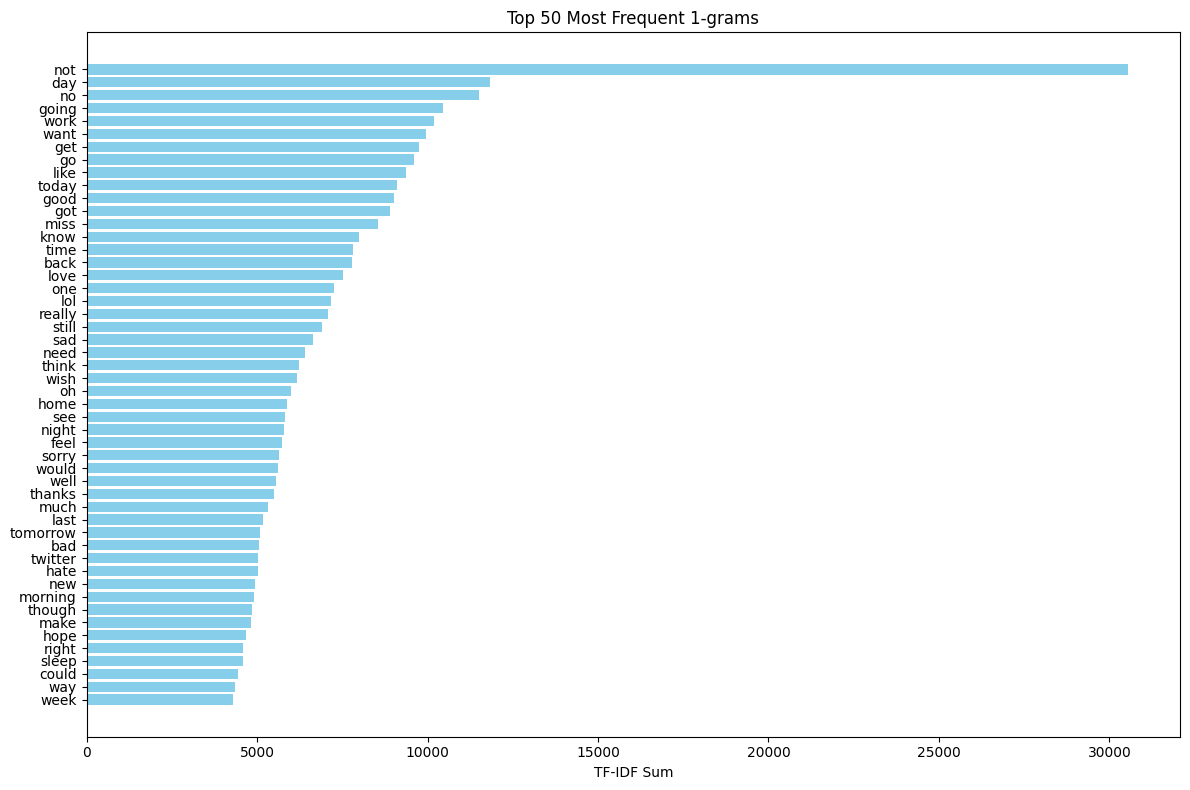

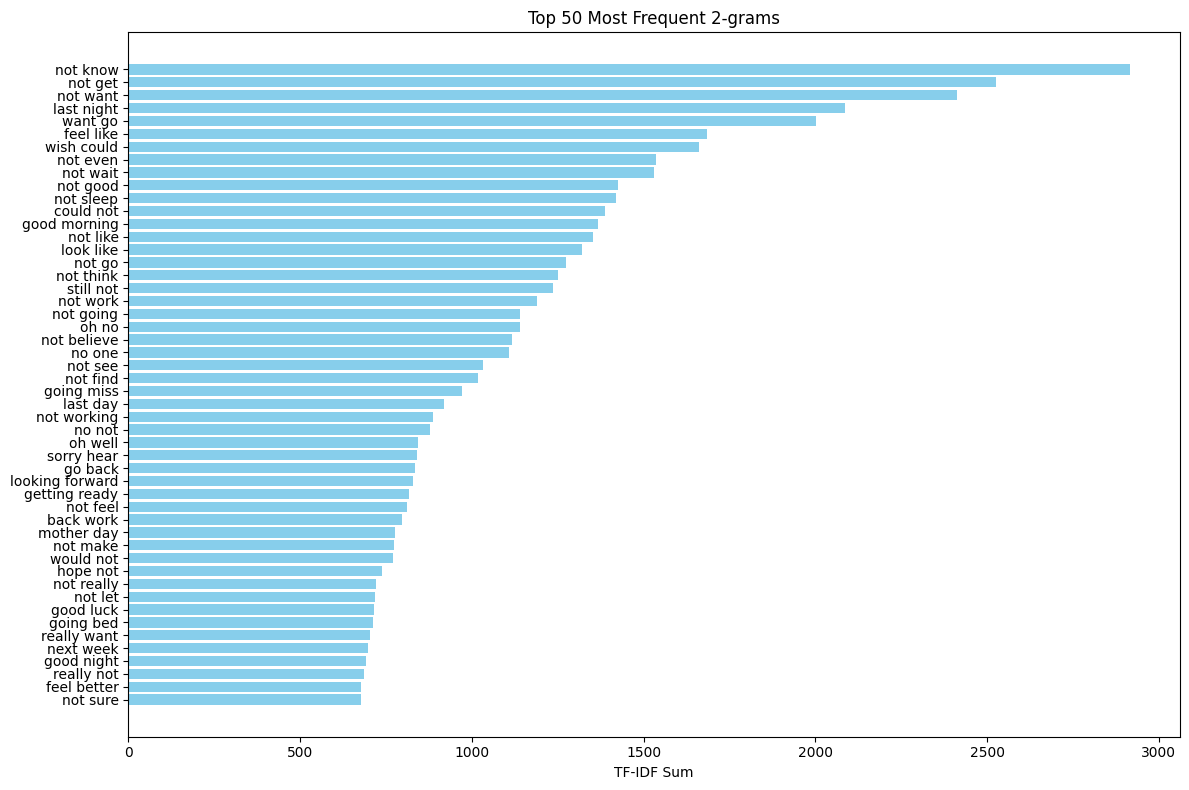

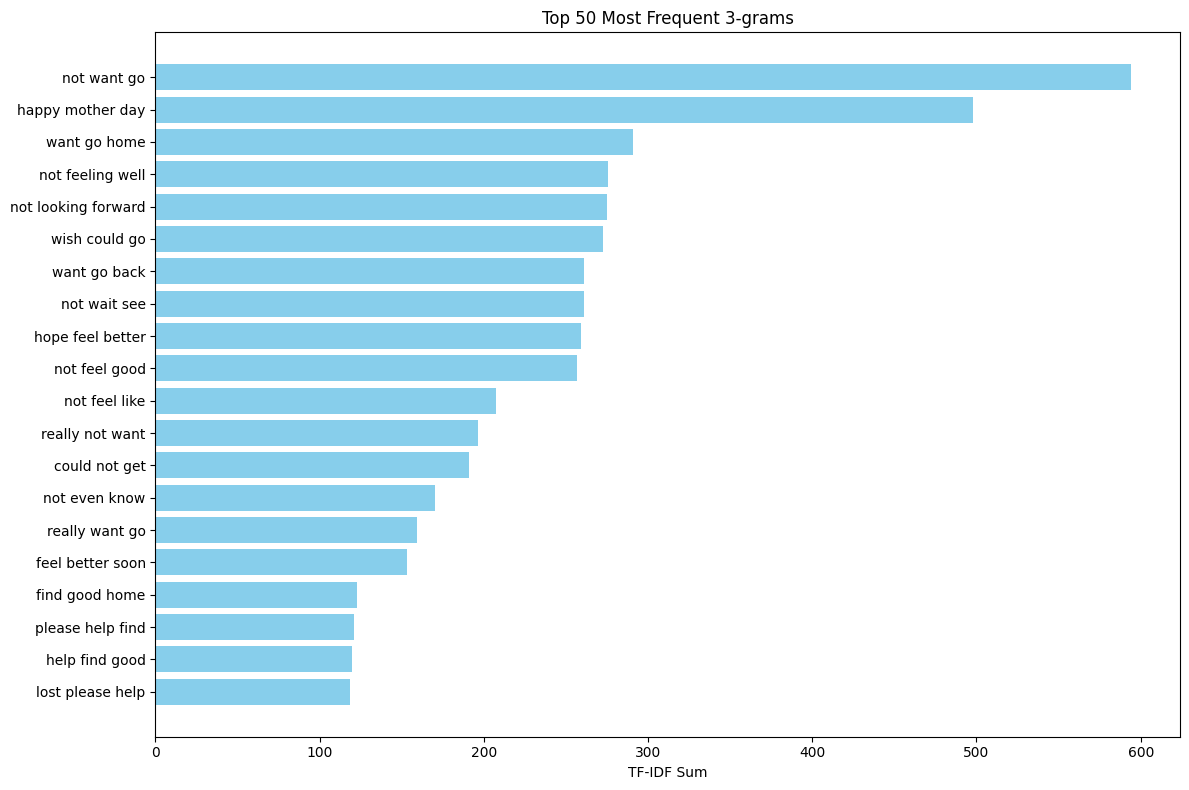

In [28]:
for n in range(ngram_range[0], ngram_range[1]+1):
    top_ngrams = df[df['ngram_length'] == n].nlargest(50, 'tfidf_sum')
    plt.figure(figsize=(12, 8))
    plt.barh(top_ngrams['ngram'], top_ngrams['tfidf_sum'], color='skyblue')
    plt.xlabel('TF-IDF Sum')
    plt.title(f'Top 50 Most Frequent {n}-grams')
    plt.gca().invert_yaxis()
    plt.tight_layout()

The comparison between unigram, bigram, and trigram TF-IDF plots clearly shows that meaning is better captured with bi- and tri-grams than with unigrams. While unigrams like "not" and "no" appear frequently, they lack context and do not convey complete sentiment or intent. In contrast, bigrams such as "not know" and "not get," and trigrams like "not want go" or "want go home" provide richer semantic information by preserving word relationships and phrase-level meaning. This highlights the advantage of using higher-order n-grams in representing short texts like tweets, especially when trying to capture nuanced expressions such as negation or intent.

In [29]:
combined_df = pd.concat([X_train, y_train], axis=1)

norms = np.linalg.norm(tfidf_train.toarray(), axis=1)

norms = np.round(norms).astype(int)

combined_df["tfidf_norm"] = norms

In [30]:
combined_df[combined_df["tfidf_norm"] == 0]

,padded_text,polarity,tfidf_norm
380466,robbie crowd,0,0
888132,wee hoppusday,4,0
383923,backstreet relationship,0,0
861391,wubs,4,0
809584,priscila,4,0
...,...,...,...
902151,imtetsting visual,4,0
905406,,4,0
176167,avoiding,0,0
885262,,4,0


<Axes: xlabel='tfidf_norm', ylabel='count'>

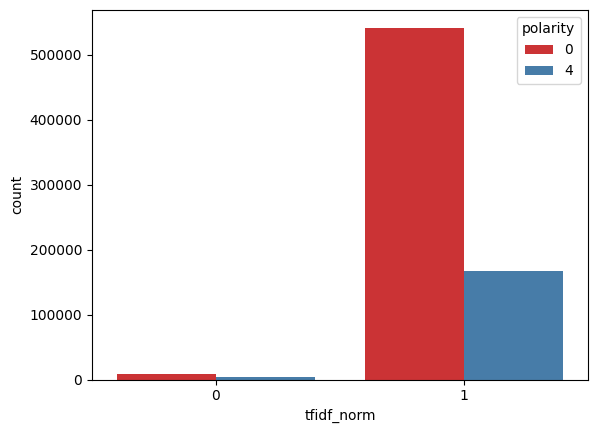

In [31]:
sns.countplot(data=combined_df, x="tfidf_norm", hue="polarity", palette="Set1")

Despite applying TF-IDF vectorization across approximately 500,000 tweets, we found that around 13,000 entries were not captured at all, as indicated by their tfidf_norm values being zero. This issue persisted even after padding and n-gram expansion. A closer inspection suggests that some tweets were either composed of infrequent or highly filtered tokens, or were entirely stripped during preprocessing—especially if they contained only stopwords, emojis, or non-standard words. As a result, these tweets ended up with no valid tokens for TF-IDF to process, making them invisible to the model. This highlights a key limitation of TF-IDF in handling noisy or ultra-short social media text, where aggressive preprocessing and sparse vocabulary can lead to complete loss of semantic representation.

## Model & Training

In [32]:
train_vectors = tfidf_train.toarray()
print(train_vectors.shape)
test_vectors = tfidf_test.toarray()
print(test_vectors.shape)

(723019, 2048)
(309866, 2048)


In [33]:
# converting the features_train and features_validation 
train_vectors = torch.tensor(train_vectors, dtype=torch.float32)
test_vectors = torch.tensor(test_vectors, dtype=torch.float32)

In [34]:
# convert target variables into pytorch tensors
label_map = {0: 0, 4: 1}

y_train = torch.tensor(y_train["polarity"].map(label_map).to_numpy(), dtype=torch.long)
y_test = torch.tensor(y_test["polarity"].map(label_map).to_numpy(), dtype=torch.long)

In [43]:
# initialise TensorDataset  object
train_dataset = TensorDataset(train_vectors, y_train)
test_dataset = TensorDataset(test_vectors, y_test)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=True)

In [44]:
class ANNModel(nn.Module):
    def __init__(self, input_size, hidden_size=16, output_size=2, dropout_rate=0.43):
        super(ANNModel, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(hidden_size, output_size)
        # No activation here; use CrossEntropyLoss during training

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        return out  # raw logits

In [45]:
model = ANNModel(input_size=train_vectors.shape[1])

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

In [46]:
num_epochs = 10  # Number of epochs
losses = []  # List to store the average loss per epoch
test_losses = []

for epoch in range(num_epochs):
    model.train()  # Set the model to training mode
    total_loss = 0  # Variable to store the total loss in each epoch
    total_test_loss = 0
    count = 0  # Variable to count the number of batches
    test_count = 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        outputs = outputs
        loss = criterion(outputs, labels) 
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        count += 1
    average_loss = total_loss / count  # Calculate average loss for the epoch
    losses.append(average_loss)  # Append average loss to the list
       
    for inputs, labels in test_loader:
        test_outputs = model(inputs)
        test_outputs = test_outputs
        test_loss = criterion(test_outputs, labels)
        total_test_loss += test_loss.item()
        test_count += 1
    average_test_loss = total_test_loss / test_count  # Calculate average loss for the epoch
    test_losses.append(average_test_loss)  # Append average loss to the list
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {average_loss:.4f}, Test Loss: {average_test_loss:.4f}')

Epoch 1/10, Loss: 0.4202, Test Loss: 0.3914
Epoch 2/10, Loss: 0.3876, Test Loss: 0.3885
Epoch 3/10, Loss: 0.3853, Test Loss: 0.3885
Epoch 4/10, Loss: 0.3840, Test Loss: 0.3875
Epoch 5/10, Loss: 0.3830, Test Loss: 0.3877
Epoch 6/10, Loss: 0.3823, Test Loss: 0.3874
Epoch 7/10, Loss: 0.3816, Test Loss: 0.3872
Epoch 8/10, Loss: 0.3814, Test Loss: 0.3872
Epoch 9/10, Loss: 0.3804, Test Loss: 0.3865
Epoch 10/10, Loss: 0.3801, Test Loss: 0.3861


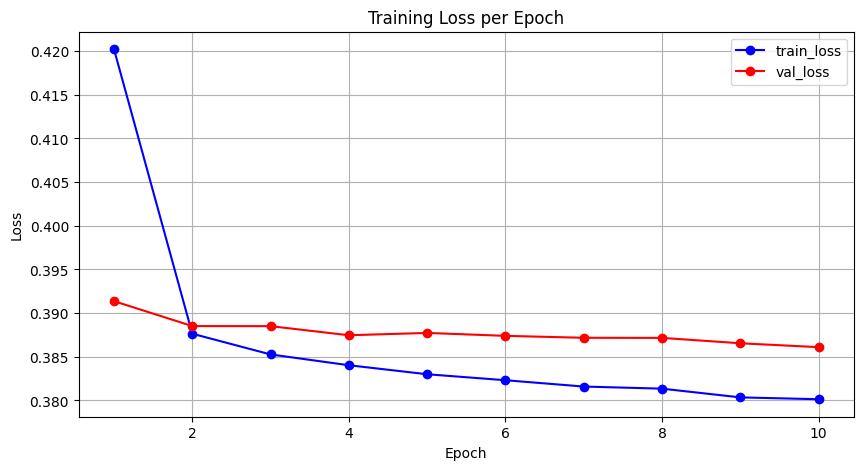

In [47]:
# Plotting the training loss
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), losses, marker='o', linestyle='-', color='b', label = 'train_loss')
plt.plot(range(1, num_epochs + 1), test_losses, marker='o', linestyle='-', color='r', label = 'val_loss')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## Evaluation

In [50]:
def evaluate_model(loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in loader:
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    error_rate = 1 - accuracy
    balanced_accuracy = balanced_accuracy_score(all_labels, all_preds)
    conf_matrix = confusion_matrix(all_labels, all_preds)

    return accuracy * 100, error_rate * 100, balanced_accuracy * 100, conf_matrix

train_accuracy, train_error_rate, train_bal_acc, train_conf_matrix = evaluate_model(train_loader)
val_accuracy, val_error_rate, val_bal_acc, val_conf_matrix = evaluate_model(test_loader)

In [55]:
print(f'Training Accuracy: {train_accuracy:.2f}%')
print(f'Training Error Rate: {train_error_rate:.2f}%')
print(f'Training Balanced Accuracy: {train_bal_acc:.2f}%')

print(f'Test Accuracy: {val_accuracy:.2f}%')
print(f'Test Error Rate: {val_error_rate:.2f}%')
print(f'Test Balanced Accuracy: {val_bal_acc:.2f}%')

Training Accuracy: 83.94%
Training Error Rate: 16.06%
Training Balanced Accuracy: 71.44%
Test Accuracy: 83.52%
Test Error Rate: 16.48%
Test Balanced Accuracy: 70.85%


In [53]:
def plot_confusion_matrix(conf_matrix, title):
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.tight_layout()
    plt.show()

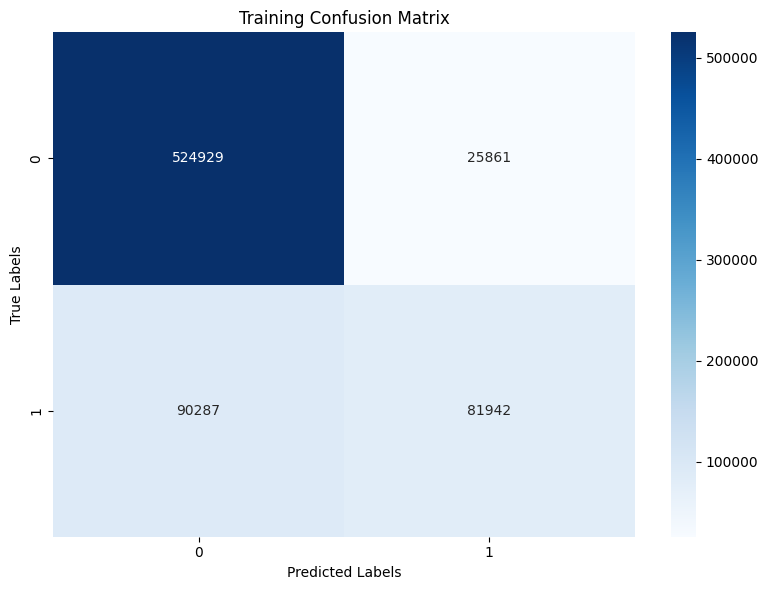

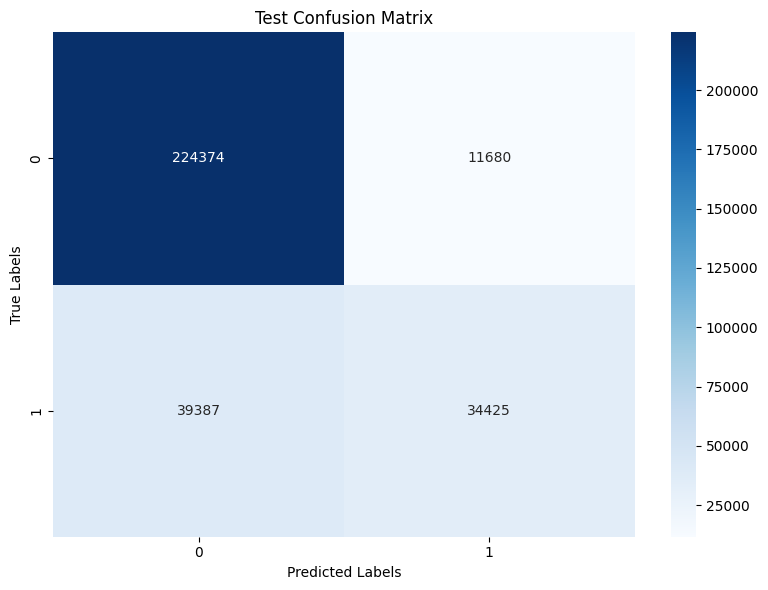

In [56]:
plot_confusion_matrix(train_conf_matrix, 'Training Confusion Matrix')
plot_confusion_matrix(val_conf_matrix, 'Test Confusion Matrix')

The model achieved a **high overall accuracy** of approximately **83.5%** on the test set, which initially suggests strong performance. However, the **balanced accuracy** is notably lower at **70.85%**, indicating that the model performs unevenly across the two sentiment classes. This discrepancy is largely due to the **imbalance in the target labels**, where the model tends to favor predicting the majority class—**negative sentiment (label 0)**—over the minority class—**positive sentiment (label 1)**. The confusion matrix confirms this bias, showing a significantly higher number of false negatives (positive tweets misclassified as negative) than false positives.

To address this issue, we propose several mitigation strategies:

1. **Oversampling the Minority Class**: Duplicate or synthetically generate more positive sentiment tweets (e.g., using SMOTE or simple duplication) to balance the training data.

2. **Focal Loss**: Replace standard loss functions with focal loss, which focuses learning on hard-to-classify examples and reduces the influence of well-classified majority samples.